<a href="https://colab.research.google.com/github/Roshni-AngelAlex/MACHINE-LEARNING-LAB-24ADI003-/blob/main/MLLABEX8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MACHINE LEARNING**

**LAB EXPERIMENT 8**

**Association Rule Learning (Apriori Algorithm) and
Dimensionality Reduction (PCA)**


**NAME : ROSHNI ANGEL A / ROLLNO: 24BAD101**

SCENARIO 1 – ASSOCIATION RULE MINING USING APRIORI ALGORITHM

Problem Statement

Identify frequent itemsets and generate association rules from transactional data using the Apriori algorithm.

Dataset (Kaggle – Public)
Market Basket Dataset / Grocery Dataset

Example:

https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset


Target Variable: Association rules

(frequent item relationships)

Input Feature:

• Transaction ID

• Items purchased



Saving Groceries_dataset.csv to Groceries_dataset (2).csv
Frequent Itemsets:
    support         itemsets
0  0.078502       (UHT-milk)
1  0.031042  (baking powder)
2  0.119548           (beef)
3  0.079785        (berries)
4  0.062083      (beverages)

Association Rules:
                          antecedents               consequents   support  \
0                          (UHT-milk)        (other vegetables)  0.038994   
1                          (UHT-milk)              (rolls/buns)  0.031042   
2                          (UHT-milk)                    (soda)  0.027450   
3                          (UHT-milk)              (whole milk)  0.040534   
4                              (beef)        (other vegetables)  0.050795   
..                                ...                       ...       ...   
863                 (sausage, yogurt)  (whole milk, rolls/buns)  0.022832   
864    (whole milk, rolls/buns, soda)                  (yogurt)  0.024628   
865  (whole milk, rolls/buns, yogurt

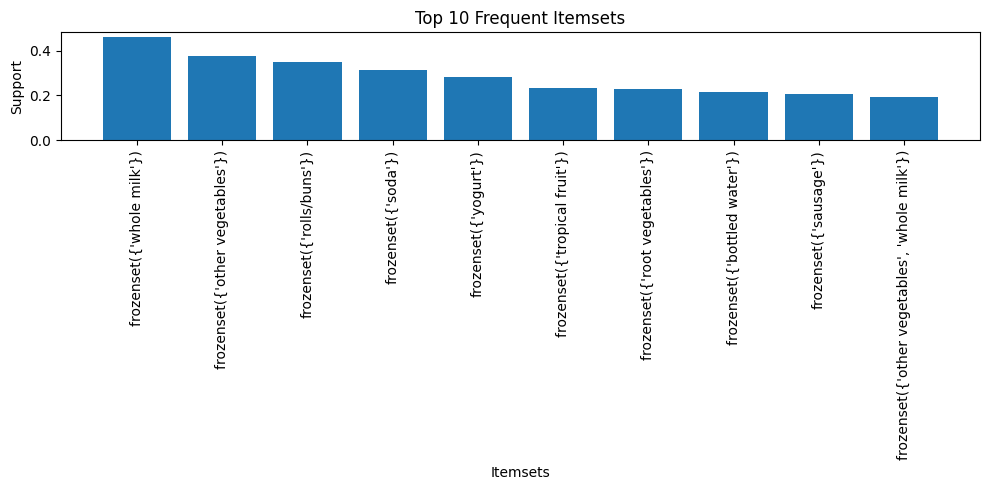

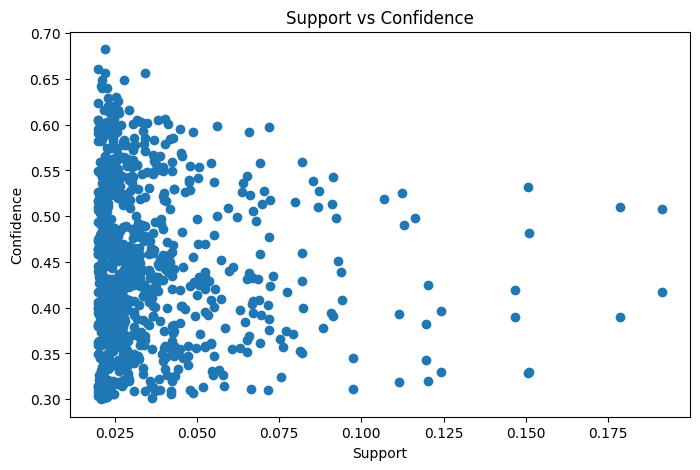

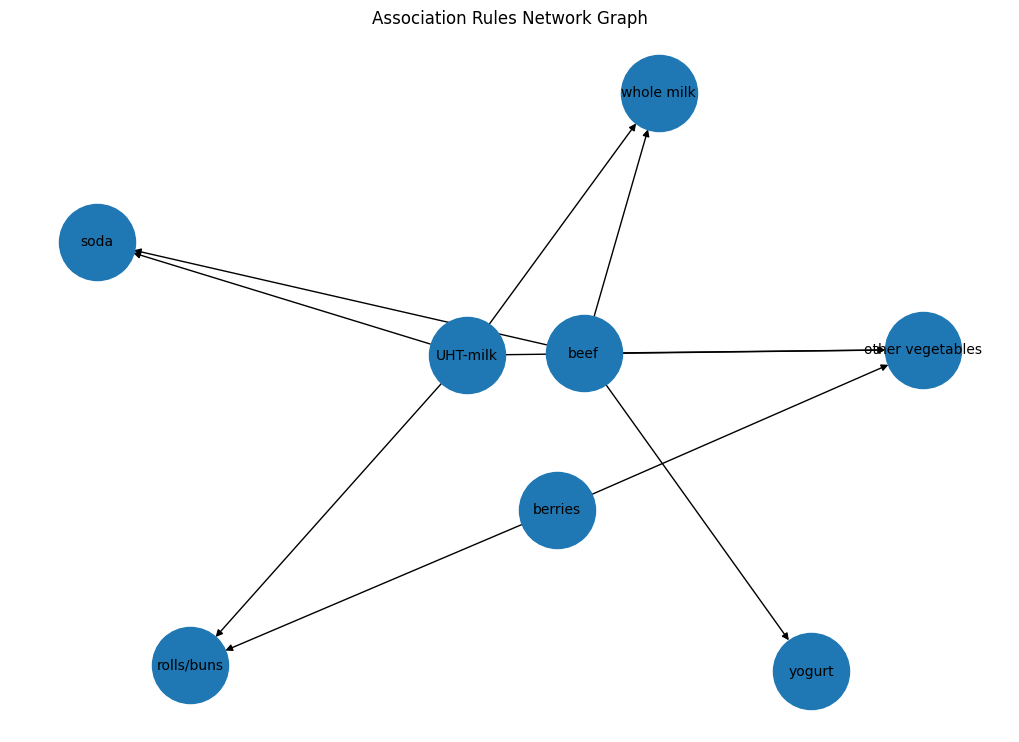

In [5]:
# EXPT NO: 8
# Association Rule Mining using Apriori Algorithm
# Name   : ROSHNI ANGEL A
# Roll No: 24BAD101

# Suppress warnings
import os
import warnings
import logging

os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")
logging.getLogger('py.warnings').setLevel(logging.ERROR)

# Install required libraries
!pip install -q mlxtend networkx

# Import required libraries
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import networkx as nx
from google.colab import files

# Upload dataset
uploaded = files.upload()

# Load dataset
data = pd.read_csv('Groceries_dataset.csv')

# Convert dataset into transaction format
transactions = data.groupby('Member_number')['itemDescription'].apply(list).values.tolist()

# One-hot encoding
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

# Generate frequent itemsets
frequent_itemsets = apriori(df, min_support=0.02, use_colnames=True)

# Display frequent itemsets
print("Frequent Itemsets:")
print(frequent_itemsets.head())

# Generate association rules
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.3)

# Filter rules with lift > 1
rules = rules[rules['lift'] > 1]

# Display rules
print("\nAssociation Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# Bar chart of top 10 frequent itemsets
top_items = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(range(len(top_items)), top_items['support'])
plt.xticks(range(len(top_items)), [str(i) for i in top_items['itemsets']], rotation=90)
plt.xlabel("Itemsets")
plt.ylabel("Support")
plt.title("Top 10 Frequent Itemsets")
plt.tight_layout()
plt.show()

# Support vs Confidence scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(rules['support'], rules['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()

# Network graph of association rules
G = nx.DiGraph()

for _, row in rules.head(10).iterrows():
    antecedent = list(row['antecedents'])[0]
    consequent = list(row['consequents'])[0]
    G.add_edge(antecedent, consequent)

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=3000, font_size=10)
plt.title("Association Rules Network Graph")
plt.show()

SCENARIO 2 – DIMENSIONALITY REDUCTION USING PCA

Problem Statement

Reduce high-dimensional data into lower dimensions while preserving maximum variance using PCA.

Dataset (Kaggle – Public) Wine dataset

dataset link :

https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Target Variable: Principal components (reduced feature set)

Input Features

• Numerical features


Saving WineQT.csv to WineQT.csv
Explained Variance Ratio:
[0.27194409 0.15872089 0.13585374 0.10096166 0.08046427 0.07449103
 0.05187962 0.04467196 0.03480083 0.02701673 0.01435664 0.00483854]

Cumulative Variance:
[0.27194409 0.43066498 0.56651872 0.66748038 0.74794465 0.82243568
 0.8743153  0.91898726 0.9537881  0.98080482 0.99516146 1.        ]


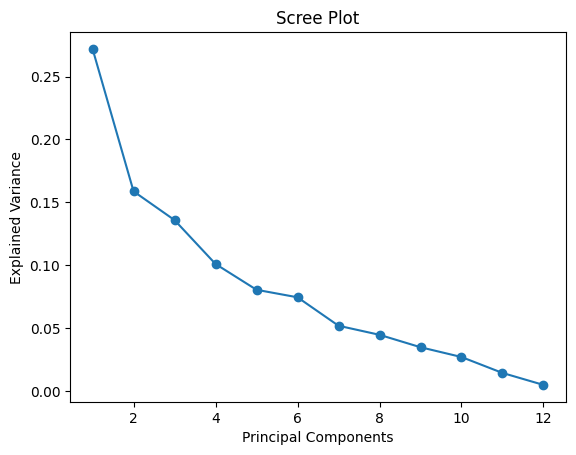

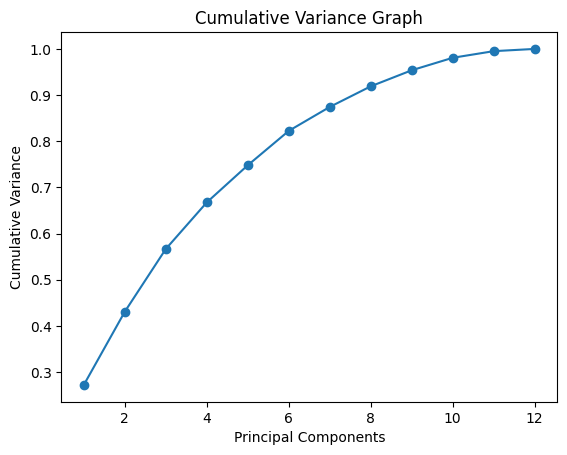

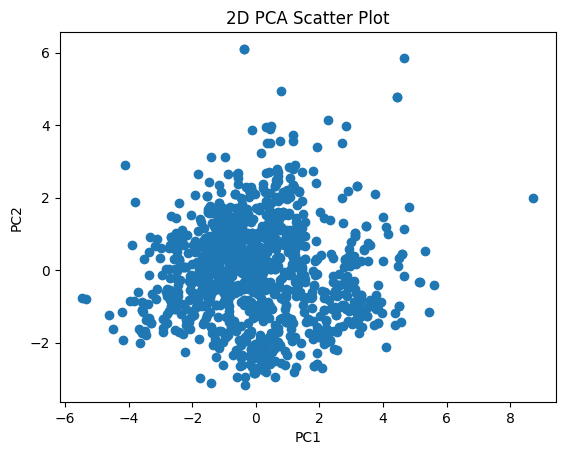

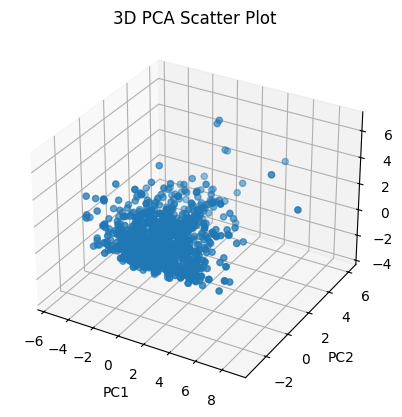

In [2]:
# EXPT NO: 8
# Dimensionality Reduction using PCA
# Name   : ROSHNI ANGEL A
# Roll No: 24BAD101

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import files

# Upload dataset
uploaded = files.upload()

# Load dataset
data = pd.read_csv('WineQT.csv')

# Select only numerical columns
data = data.select_dtypes(include=['float64', 'int64'])

# Handle missing values
data = data.dropna()

# Separate features
X = data.drop(columns=['quality'], errors='ignore')

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print("Explained Variance Ratio:")
print(explained_variance)

print("\nCumulative Variance:")
print(cumulative_variance)

# Scree plot
plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.show()

# Cumulative variance graph
plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Variance")
plt.title("Cumulative Variance Graph")
plt.show()

# PCA with 2 components
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Scatter Plot")
plt.show()

# PCA with 3 components
from mpl_toolkits.mplot3d import Axes3D

pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3[:, 0], X_pca_3[:, 1], X_pca_3[:, 2])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("3D PCA Scatter Plot")
plt.show()